In [ ]:
# This notebook will get the true nexus files and the selected events to plot the signal efficiencies

import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D 
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors 
import glob

import sys
sys.path.append("../scripts")
from TrackReconstruction_functions import *
from reconstruction_functions import *

%matplotlib widget

shifts = np.array([6.2, 3.6, 2.9, 2.5, 2.1])*1000/2.0

In [115]:
# Per sample, load time is: 
def LoadFiles(filepath):
    
    files = glob.glob(filepath)
    
    
    parts = []
    for i, f in enumerate(files):
        if i %500 ==0:
            print(f"{i} /", len(files))
        part = pd.read_hdf(f, "MC/particles", columns=["event_id","primary","particle_id", "initial_z", "final_z", "kin_energy"])
        part = part[part.primary == 1]
        parts.append(part)
        # display(parts)
        # break
    
    return pd.concat(parts)



In [116]:


basepath = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ATPC_0nubb/"
nubb_25bar = LoadFiles(f"{basepath}/25bar/nexus/*.h5")
nubb_15bar = LoadFiles(f"{basepath}/15bar/nexus/*.h5")
nubb_10bar = LoadFiles(f"{basepath}/10bar/nexus/*.h5")
nubb_5bar = LoadFiles(f"{basepath}/5bar/nexus/*.h5")
nubb_1bar = LoadFiles(f"{basepath}/1bar/nexus/*.h5")

0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 2996
500 / 2996
1000 / 2996
1500 / 2996
2000 / 2996
2500 / 2996


In [121]:
# Function gives the lowest energy electron as the final position
# Then normalizes so its range is from 0->1
def GetBlob2Pos(df, shift):
    
    # Order by event id and reset the indexes
    df = df.sort_values("event_id")
    df = df.reset_index(drop=True)
    
    idx = df.groupby('event_id')['kin_energy'].idxmin()
    lowest_energy_particles = df.loc[idx]
    
    lowest_energy_particles["norm_zi"] = (lowest_energy_particles.initial_z + shift)/ (shift*2.0)
    lowest_energy_particles["norm_zf"] = (lowest_energy_particles.final_z + shift)/ (shift*2.0)
    
    return lowest_energy_particles

# Adds the asymetry as a df column
def CalcAsymmetry(df):
    # 1. Pivot or Filter to get energies per event
    # We use a pivot to align particle_id 1 and 2 side-by-side for every event_id
    energies = df.pivot(index='event_id', columns='particle_id', values='kin_energy')
    
    asymmetry = np.abs((energies[1] - energies[2]) / (energies[1] + energies[2]))

    df['A'] = df['event_id'].map(asymmetry)
    
    return df

nubb_25bar_norm = CalcAsymmetry(nubb_25bar)
nubb_15bar_norm = CalcAsymmetry(nubb_15bar)
nubb_10bar_norm = CalcAsymmetry(nubb_10bar)
nubb_5bar_norm  = CalcAsymmetry(nubb_5bar)
nubb_1bar_norm  = CalcAsymmetry(nubb_1bar)

display(nubb_1bar_norm)

# This returns a dataframe with a normalized z-position and adds a blob2 positon
nubb_25bar_norm = GetBlob2Pos(nubb_25bar_norm, shifts[4])
nubb_15bar_norm = GetBlob2Pos(nubb_15bar_norm, shifts[3])
nubb_10bar_norm = GetBlob2Pos(nubb_10bar_norm, shifts[2])
nubb_5bar_norm  = GetBlob2Pos(nubb_5bar_norm,  shifts[1])
nubb_1bar_norm  = GetBlob2Pos(nubb_1bar_norm,  shifts[0])

display(nubb_1bar_norm)

,event_id,primary,particle_id,initial_z,final_z,kin_energy,A
0,137250,1,2,1922.032349,2335.560303,1.343568,0.093296
365,137250,1,1,1922.032349,2012.014038,1.114262,0.093296
633,137251,1,2,1026.690430,1061.596436,0.472917,0.615175
731,137251,1,1,1026.690430,1414.430176,1.984913,0.615175
1985,137253,1,2,-153.521805,68.160118,0.896781,0.270266
...,...,...,...,...,...,...,...
41841,142193,1,1,808.575073,966.054138,1.207019,0.017817
42137,142194,1,2,2630.779541,2624.961426,1.137162,0.074662
42421,142194,1,1,2630.779541,2766.965820,1.320668,0.074662
42732,142195,1,2,-2228.855469,-2259.573975,0.301837,0.754388


,event_id,primary,particle_id,initial_z,final_z,kin_energy,A,norm_zi,norm_zf
1,122,1,1,-1467.883545,-1580.356323,0.277532,0.774165,0.263245,0.245104
3,123,1,2,-841.604004,-681.200012,0.611252,0.502608,0.364257,0.390129
5,124,1,1,2325.982910,2444.660645,0.578139,0.529553,0.875159,0.894300
7,126,1,1,2995.210938,2909.754395,1.179539,0.040178,0.983099,0.969315
9,127,1,1,1319.025635,1686.469360,0.985103,0.198396,0.712746,0.772011
...,...,...,...,...,...,...,...,...,...
385919,366061,1,1,621.182556,290.441711,0.831566,0.323334,0.600191,0.546845
385921,366062,1,1,416.287445,492.099396,0.248819,0.797530,0.567143,0.579371
385923,366064,1,1,-1627.495117,-1456.806152,0.797401,0.351134,0.237501,0.265031
385925,366066,1,2,-53.194851,342.835663,1.079580,0.121518,0.491420,0.555296


In [134]:
# Load in all the reco files

nubb_1bar_5percent  = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_1bar_5percent_reco.h5",  "meta")
nubb_5bar_5percent  = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_5bar_5percent_reco.h5",  "meta")
nubb_10bar_5percent = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_10bar_5percent_reco.h5", "meta")
nubb_15bar_5percent = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_15bar_5percent_reco.h5", "meta")
nubb_25bar_5percent = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_25bar_5percent_reco.h5", "meta")

nubb_1bar_He  = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_1bar_0.05percent_reco.h5",  "meta")
nubb_5bar_He  = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_5bar_0.05percent_reco.h5",  "meta")
nubb_10bar_He = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_10bar_0.05percent_reco.h5", "meta")
nubb_15bar_He = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_15bar_0.05percent_reco.h5", "meta")
nubb_25bar_He = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_25bar_0.05percent_reco.h5", "meta")



In [131]:


# ------------------------------------------------------------------------
def CalcEfficiency(n, N, correct):
    efficiency = n/N
    
    # This corrects by applying energy resolution cut
    if correct:
        efficiency = 0.82*efficiency
    
    error=np.sqrt( (efficiency/N) * (1-efficiency)  )
    return efficiency, error

# ------------------------------------------------------------------------
def ApplyBlobCut(df, df_true, var, cut):
    df = df[df[var] > cut]
    return df, df_true[df_true.event_id.isin(df.event_id.unique())]
# ------------------------------------------------------------------------


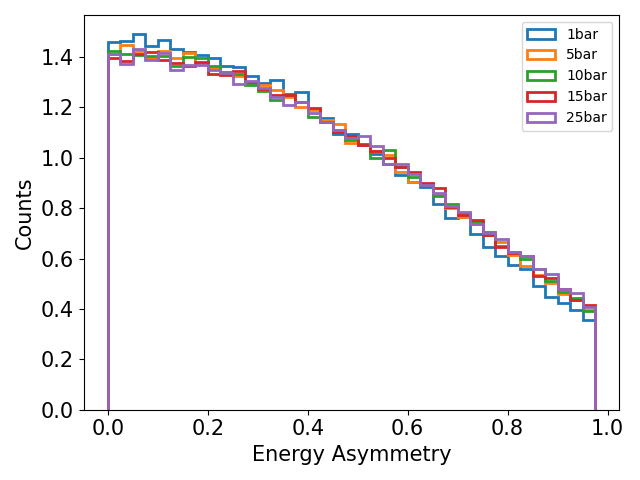

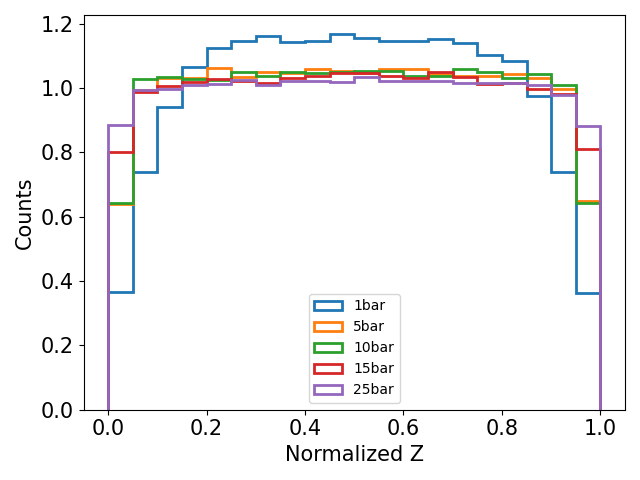

In [132]:
# display(nubb)

plt.figure()
n_gen, bins, _ = plt.hist(nubb_1bar_norm.A,  density = True,bins = np.arange(0,1,0.025), histtype="step", linewidth=2, label = "1bar");
n_gen, bins, _ = plt.hist(nubb_5bar_norm.A,  density = True,bins = np.arange(0,1,0.025), histtype="step", linewidth=2, label = "5bar");
n_gen, bins, _ = plt.hist(nubb_10bar_norm.A, density = True,bins = np.arange(0,1,0.025), histtype="step", linewidth=2, label = "10bar");
n_gen, bins, _ = plt.hist(nubb_15bar_norm.A, density = True,bins = np.arange(0,1,0.025), histtype="step", linewidth=2, label = "15bar");
n_gen, bins, _ = plt.hist(nubb_25bar_norm.A, density = True,bins = np.arange(0,1,0.025), histtype="step", linewidth=2, label = "25bar");

plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Counts", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.tight_layout()

plt.figure()
n_gen, bins, _ = plt.hist(nubb_1bar_norm.norm_zf,  density = True,bins = np.arange(0,1.05,0.05), histtype="step", linewidth=2, label = "1bar");
n_gen, bins, _ = plt.hist(nubb_5bar_norm.norm_zf,  density = True,bins = np.arange(0,1.05,0.05), histtype="step", linewidth=2, label = "5bar");
n_gen, bins, _ = plt.hist(nubb_10bar_norm.norm_zf, density = True,bins = np.arange(0,1.05,0.05), histtype="step", linewidth=2, label = "10bar");
n_gen, bins, _ = plt.hist(nubb_15bar_norm.norm_zf, density = True,bins = np.arange(0,1.05,0.05), histtype="step", linewidth=2, label = "15bar");
n_gen, bins, _ = plt.hist(nubb_25bar_norm.norm_zf, density = True,bins = np.arange(0,1.05,0.05), histtype="step", linewidth=2, label = "25bar");
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Counts", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.tight_layout()

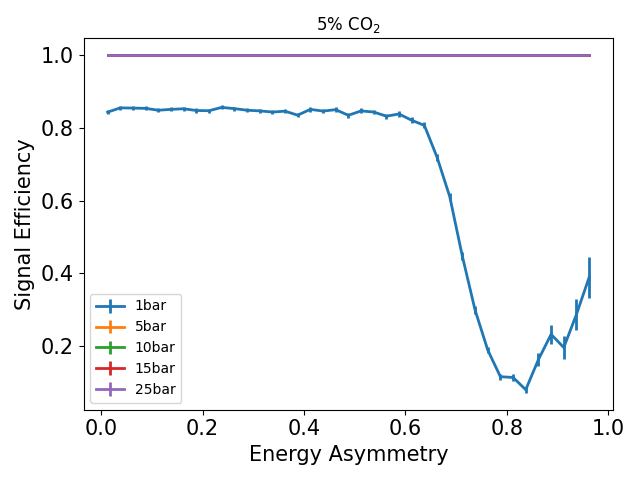

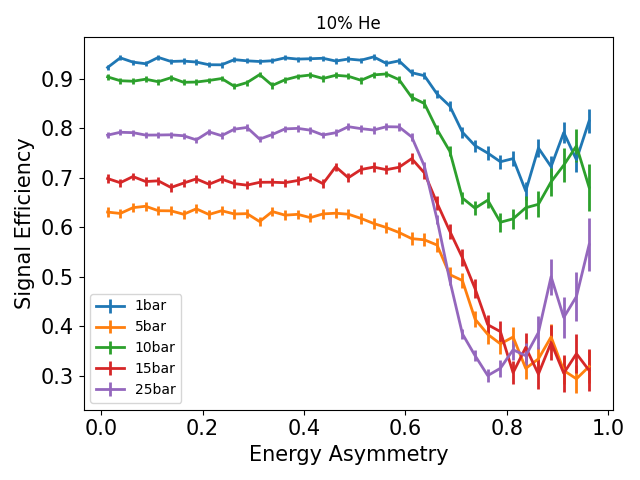

In [137]:
# Load in the event list

def GetAsymmetryHistogram(df_true, df_reco, pressure):
    
    # This ensures the event samples overlap in the reco and true
    df_true_olp = df_true[df_true.event_id.isin(df_reco.event_id.unique())]
    
    # Distribution before cuts
    n_gen, bins = np.histogram( df_true_olp.A,      bins = np.arange(0,1,0.025));
    
    # Apply the cut
    df_reco_cut, df_true_olp_cut = ApplyBlobCut(df_reco, df_true_olp, "blob2R", 0.5)
    
    n_sel, _    = np.histogram( df_true_olp_cut.A, bins = np.arange(0,1,0.025));
    efficiency, error = CalcEfficiency(n_sel, n_gen, False)
    
    # Apply the containment efficiency correction
    # efficiency = ApplyContainmentCorr(efficiency, pressure, 1)
    
    bin_centers = bins+0.025/2.0
    bin_centers = bin_centers[:-1]
    
    return efficiency, error, bin_centers


nubb_1bar_5percent_eff,  nubb_1bar_5percent_err,  nubb_1bar_5percent_bins  = GetAsymmetryHistogram(nubb_1bar_norm,  nubb_1bar_5percent, 1)
nubb_5bar_5percent_eff,  nubb_5bar_5percent_err,  nubb_5bar_5percent_bins  = GetAsymmetryHistogram(nubb_5bar_norm,  nubb_5bar_5percent, 5)
nubb_10bar_5percent_eff, nubb_10bar_5percent_err, nubb_10bar_5percent_bins = GetAsymmetryHistogram(nubb_10bar_norm, nubb_10bar_5percent, 10)
nubb_15bar_5percent_eff, nubb_15bar_5percent_err, nubb_15bar_5percent_bins = GetAsymmetryHistogram(nubb_15bar_norm, nubb_15bar_5percent, 15)
nubb_25bar_5percent_eff, nubb_25bar_5percent_err, nubb_25bar_5percent_bins = GetAsymmetryHistogram(nubb_25bar_norm, nubb_25bar_5percent, 25)


plt.figure()
plt.errorbar(nubb_1bar_5percent_bins, nubb_1bar_5percent_eff, yerr=nubb_1bar_5percent_err, linewidth = 2, label = "1bar")
plt.errorbar(nubb_5bar_5percent_bins, nubb_5bar_5percent_eff, yerr=nubb_5bar_5percent_err, linewidth = 2, label = "5bar")
plt.errorbar(nubb_10bar_5percent_bins, nubb_10bar_5percent_eff, yerr=nubb_10bar_5percent_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_15bar_5percent_bins, nubb_15bar_5percent_eff, yerr=nubb_15bar_5percent_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_25bar_5percent_bins, nubb_25bar_5percent_eff, yerr=nubb_25bar_5percent_err, linewidth = 2, label = "25bar")

plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"5% CO$_2$")
plt.tight_layout()


nubb_25bar_He_eff, nubb_25bar_He_err, nubb_25bar_He_bins = GetAsymmetryHistogram(nubb_1bar_norm,  nubb_1bar_He, 1)
nubb_15bar_He_eff, nubb_15bar_He_err, nubb_15bar_He_bins = GetAsymmetryHistogram(nubb_5bar_norm,  nubb_5bar_He, 5)
nubb_10bar_He_eff, nubb_10bar_He_err, nubb_10bar_He_bins = GetAsymmetryHistogram(nubb_10bar_norm, nubb_10bar_He, 10)
nubb_5bar_He_eff,  nubb_5bar_He_err,  nubb_5bar_He_bins  = GetAsymmetryHistogram(nubb_15bar_norm, nubb_15bar_He, 15)
nubb_1bar_He_eff,  nubb_1bar_He_err,  nubb_1bar_He_bins  = GetAsymmetryHistogram(nubb_25bar_norm, nubb_25bar_He, 25)

plt.figure()
plt.errorbar(nubb_1bar_He_bins, nubb_1bar_He_eff, yerr=nubb_1bar_He_err, linewidth = 2, label = "1bar")
plt.errorbar(nubb_5bar_He_bins, nubb_5bar_He_eff, yerr=nubb_5bar_He_err, linewidth = 2, label = "5bar")
plt.errorbar(nubb_10bar_He_bins, nubb_10bar_He_eff, yerr=nubb_10bar_He_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_15bar_He_bins, nubb_15bar_He_eff, yerr=nubb_15bar_He_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_25bar_He_bins, nubb_25bar_He_eff, yerr=nubb_25bar_He_err, linewidth = 2, label = "25bar")
plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"10% He")
plt.tight_layout()


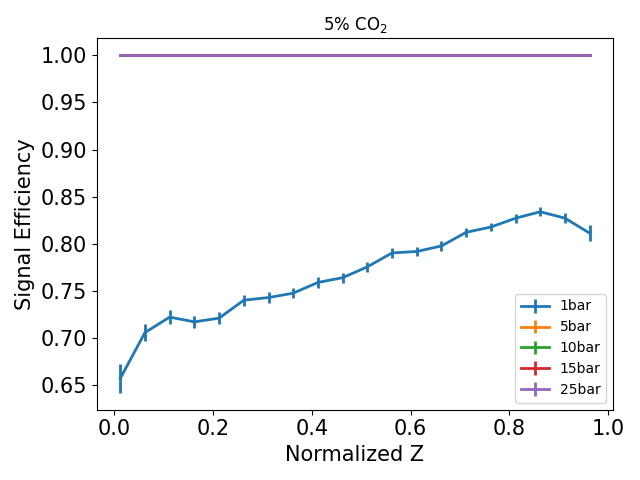

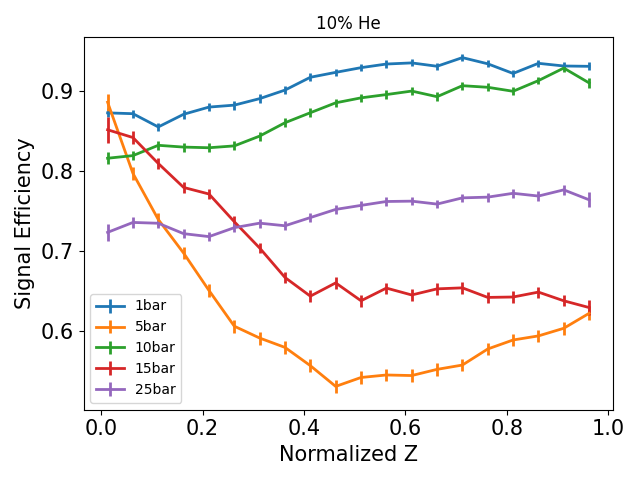

In [ ]:
# Load in the event list

def GetZPosHistogram(df_true, df_reco, pressure):
    
    # This ensures the event samples overlap in the reco and true
    df_true_olp = df_true[df_true.event_id.isin(df_reco.event_id.unique())]
    
    # Distribution before cuts
    n_gen, bins = np.histogram( df_true_olp.norm_zf,      bins = np.arange(0,1.05,0.05));
    
    # Apply the cut
    df_reco_cut, df_true_olp_cut = ApplyBlobCut(df_reco, df_true_olp, "blob2R", 0.5)
    
    n_sel, _    = np.histogram( df_true_olp_cut.norm_zf, bins = np.arange(0,1.05,0.05));
    efficiency, error = CalcEfficiency(n_sel, n_gen, False)
    
    # Apply the containment efficiency correction
    # efficiency = ApplyContainmentCorr(efficiency, pressure, 1)
    
    bin_centers = bins+0.025/2.0
    bin_centers = bin_centers[:-1]
    
    return efficiency, error, bin_centers



nubb_1bar_5percent_eff,  nubb_1bar_5percent_err,  nubb_1bar_5percent_bins  = GetZPosHistogram(nubb_1bar_norm,  nubb_1bar_5percent, 1)
nubb_5bar_5percent_eff,  nubb_5bar_5percent_err,  nubb_5bar_5percent_bins  = GetZPosHistogram(nubb_5bar_norm,  nubb_5bar_5percent, 5)
nubb_10bar_5percent_eff, nubb_10bar_5percent_err, nubb_10bar_5percent_bins = GetZPosHistogram(nubb_10bar_norm, nubb_10bar_5percent, 10)
nubb_15bar_5percent_eff, nubb_15bar_5percent_err, nubb_15bar_5percent_bins = GetZPosHistogram(nubb_15bar_norm, nubb_15bar_5percent, 15)
nubb_25bar_5percent_eff, nubb_25bar_5percent_err, nubb_25bar_5percent_bins = GetZPosHistogram(nubb_25bar_norm, nubb_25bar_5percent, 25)


plt.figure()
plt.errorbar(nubb_1bar_5percent_bins,  nubb_1bar_5percent_eff,  yerr=nubb_1bar_5percent_err,  linewidth = 2, label = "1bar")
plt.errorbar(nubb_5bar_5percent_bins,  nubb_5bar_5percent_eff,  yerr=nubb_5bar_5percent_err,  linewidth = 2, label = "5bar")
plt.errorbar(nubb_10bar_5percent_bins, nubb_10bar_5percent_eff, yerr=nubb_10bar_5percent_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_15bar_5percent_bins, nubb_15bar_5percent_eff, yerr=nubb_15bar_5percent_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_25bar_5percent_bins, nubb_25bar_5percent_eff, yerr=nubb_25bar_5percent_err, linewidth = 2, label = "25bar")
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"5% CO$_2$")
plt.tight_layout()


nubb_25bar_He_eff, nubb_25bar_He_err, nubb_25bar_He_bins = GetZPosHistogram(nubb_1bar_norm,  nubb_1bar_He, 1)
nubb_15bar_He_eff, nubb_15bar_He_err, nubb_15bar_He_bins = GetZPosHistogram(nubb_5bar_norm,  nubb_5bar_He, 5)
nubb_10bar_He_eff, nubb_10bar_He_err, nubb_10bar_He_bins = GetZPosHistogram(nubb_10bar_norm, nubb_10bar_He, 10)
nubb_5bar_He_eff,  nubb_5bar_He_err,  nubb_5bar_He_bins  = GetZPosHistogram(nubb_15bar_norm, nubb_15bar_He, 15)
nubb_1bar_He_eff,  nubb_1bar_He_err,  nubb_1bar_He_bins  = GetZPosHistogram(nubb_25bar_norm, nubb_25bar_He, 25)

plt.figure()
plt.errorbar(nubb_1bar_He_bins,  nubb_1bar_He_eff,  yerr=nubb_1bar_He_err,  linewidth = 2, label = "1bar")
plt.errorbar(nubb_5bar_He_bins,  nubb_5bar_He_eff,  yerr=nubb_5bar_He_err,  linewidth = 2, label = "5bar")
plt.errorbar(nubb_10bar_He_bins, nubb_10bar_He_eff, yerr=nubb_10bar_He_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_15bar_He_bins, nubb_15bar_He_eff, yerr=nubb_15bar_He_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_25bar_He_bins, nubb_25bar_He_eff, yerr=nubb_25bar_He_err, linewidth = 2, label = "25bar")
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"10% He")
plt.tight_layout()
